# MobileRec

[MobileRec](https://huggingface.co/datasets/recmeapp/mobilerec) is a large-scale mobile app recommendation dataset (~19.3M user–item interactions, 5-core filtered). Load **interactions** and **app metadata** separately via `data_dir` (the repo mixes different CSV schemas in one folder).

In [1]:
%pip install -q datasets pandas huggingface_hub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from datasets import load_dataset

# User–item interactions (reviews, ratings, timestamps, …)
interactions = load_dataset("recmeapp/mobilerec", data_dir="interactions")

# App catalog metadata (name, developer, category, …)
app_meta = load_dataset("recmeapp/mobilerec", data_dir="app_meta")

interactions, app_meta

interactions/mobilerec_final.csv:   0%|          | 0.00/4.42G [00:00<?, ?B/s]

c:\Users\joaquim.motger\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\joaquim.motger\.cache\huggingface\hub\datasets--recmeapp--mobilerec. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Generating train split: 0 examples [00:00, ? examples/s]

app_meta/app_meta.csv:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

(DatasetDict({
     train: Dataset({
         features: ['app_package', 'review', 'rating', 'votes', 'date', 'uid', 'formated_date', 'unix_timestamp', 'app_category'],
         num_rows: 19297019
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['app_package', 'app_name', 'developer_name', 'app_category', 'description', 'content_rating', 'num_reviews', 'price', 'avg_rating'],
         num_rows: 10173
     })
 }))

In [3]:
# First rows (streaming-friendly; avoids loading the full ~4 GB into memory)
interactions["train"][:3]

{'app_package': ['com.cleverapps.heroes',
  'com.bodyfast',
  'com.thrivegames.wordshapes'],
 'review': ["It's really a fun game",
  'uninstalling. it was ok but felt like it was controlling the hours and especially how many days you would fast. not best for creating your own and tracking progress.',
  'Love this game'],
 'rating': [5, 2, 4],
 'votes': [1, 0, 1],
 'date': ['October 21, 2018', 'January 18, 2019', 'January 16, 2021'],
 'uid': ['shqoc6X1fcJRLEmx', 'shqoc6X1fcJRLEmx', 'shqoc6X1fcJRLEmx'],
 'formated_date': ['2018-10-21', '2019-01-18', '2021-01-16'],
 'unix_timestamp': [1540094400.0, 1547787600.0, 1610773200.0],
 'app_category': ['Casual', 'Health & Fitness', 'Word']}

In [4]:
app_meta["train"][:3]

{'app_package': ['com.natewren.lines',
  'com.capitalone.credittracker',
  'com.purascents.android'],
 'app_name': ['Lines Pro - Icon Pack',
  'CreditWise from Capital One',
  'Pura - Smart Fragrance Dispenser'],
 'developer_name': ['Nate Wren Design', 'Capital One Services, LLC', 'Pura'],
 'app_category': ['Personalization', 'Finance', 'House & Home'],
 'description': ['Lines icons (pro version) are outlined shapes of the most popular apps. Included with the hand-crafted line icons are matching wallpapers, and widgets for clocks, battery and weather. Widgets offer color, size, and font customization and over 200 hand-picked wallpapers of skies, clouds, landscapes and abstract designs are included. The center of the icon outline is transparent, letting you show off your wallpaper beneath the icons. The line icons are xxxhdpi which means they\'re HD or high enough resolution to get cool looking lined icons on any device out there.\n\n\nQUICK TIPS\nYou can manually edit icons in most lau

In [5]:
train = interactions["train"]
meta = app_meta["train"]

print(f"Interactions: {train.num_rows:,} rows — {train.column_names}")
print(f"App metadata: {meta.num_rows:,} rows — {meta.column_names}")

Interactions: 19,297,019 rows — ['app_package', 'review', 'rating', 'votes', 'date', 'uid', 'formated_date', 'unix_timestamp', 'app_category']
App metadata: 10,173 rows — ['app_package', 'app_name', 'developer_name', 'app_category', 'description', 'content_rating', 'num_reviews', 'price', 'avg_rating']


In [10]:
sorted_app_categories = sorted(set(meta["app_category"]))
sorted_app_categories

['Action',
 'Adventure',
 'Arcade',
 'Art & Design',
 'Auto & Vehicles',
 'Beauty',
 'Board',
 'Books & Reference',
 'Business',
 'Card',
 'Casino',
 'Casual',
 'Comics',
 'Communication',
 'Dating',
 'Education',
 'Educational',
 'Entertainment',
 'Events',
 'Finance',
 'Food & Drink',
 'Health & Fitness',
 'House & Home',
 'Libraries & Demo',
 'Lifestyle',
 'Maps & Navigation',
 'Medical',
 'Music',
 'Music & Audio',
 'News & Magazines',
 'Parenting',
 'Personalization',
 'Photography',
 'Productivity',
 'Puzzle',
 'Racing',
 'Role Playing',
 'Shopping',
 'Simulation',
 'Social',
 'Sports',
 'Strategy',
 'Tools',
 'Travel & Local',
 'Trivia',
 'Video Players & Editors',
 'Weather',
 'Word']

In [11]:
app_categories_filtered = ["Education", "Business", "Tools", "Food & Drink", "Lifestyle", "Productivity", "Health & Fitness", "Finance", "Shopping", "Music & Audio"]

In [13]:
import pyarrow as pa
import pyarrow.compute as pc
import pandas as pd

name_by_package = dict(zip(meta["app_package"], meta["app_name"]))

# Filter by category in Arrow (C++), then group_by — avoids train.iter() → Python dicts
table = train.data.table
mask = pc.is_in(table["app_category"], value_set=pa.array(app_categories_filtered))
sub = table.filter(mask).select(["app_category", "app_package"])

counts_df = (
    sub.group_by(["app_category", "app_package"])
    .aggregate([("app_package", "count")])
    .to_pandas()
    .rename(columns={"app_package_count": "interactions"})
)

top_10_apps_per_category = (
    counts_df.sort_values(["app_category", "interactions"], ascending=[True, False])
    .groupby("app_category", as_index=False)
    .head(10)
    .assign(rank=lambda d: d.groupby("app_category").cumcount() + 1)
    .assign(app_name=lambda d: d["app_package"].map(name_by_package))
    [["app_category", "rank", "app_package", "app_name", "interactions"]]
    .reset_index(drop=True)
)

top_10_apps_per_category

,app_category,rank,app_package,app_name,interactions
0,Business,1,us.zoom.videomeetings,ZOOM Cloud Meetings,10904
1,Business,2,com.microsoft.teams,Microsoft Teams,6704
2,Business,3,com.google.android.apps.meetings,Google Meet,6366
3,Business,4,com.doordash.driverapp,DoorDash - Dasher,6067
4,Business,5,com.cisco.webex.meetings,Webex Meetings,5755
...,...,...,...,...,...
95,Tools,6,com.expressvpn.vpn,ExpressVPN: Fast & Private VPN,6252
96,Tools,7,com.google.ar.lens,Google Lens,6208
97,Tools,8,com.immediasemi.android.blink,Blink Home Monitor — Smart Home Security App,6104
98,Tools,9,com.samsung.android.app.watchmanager,Galaxy Wearable (Samsung Gear),6038


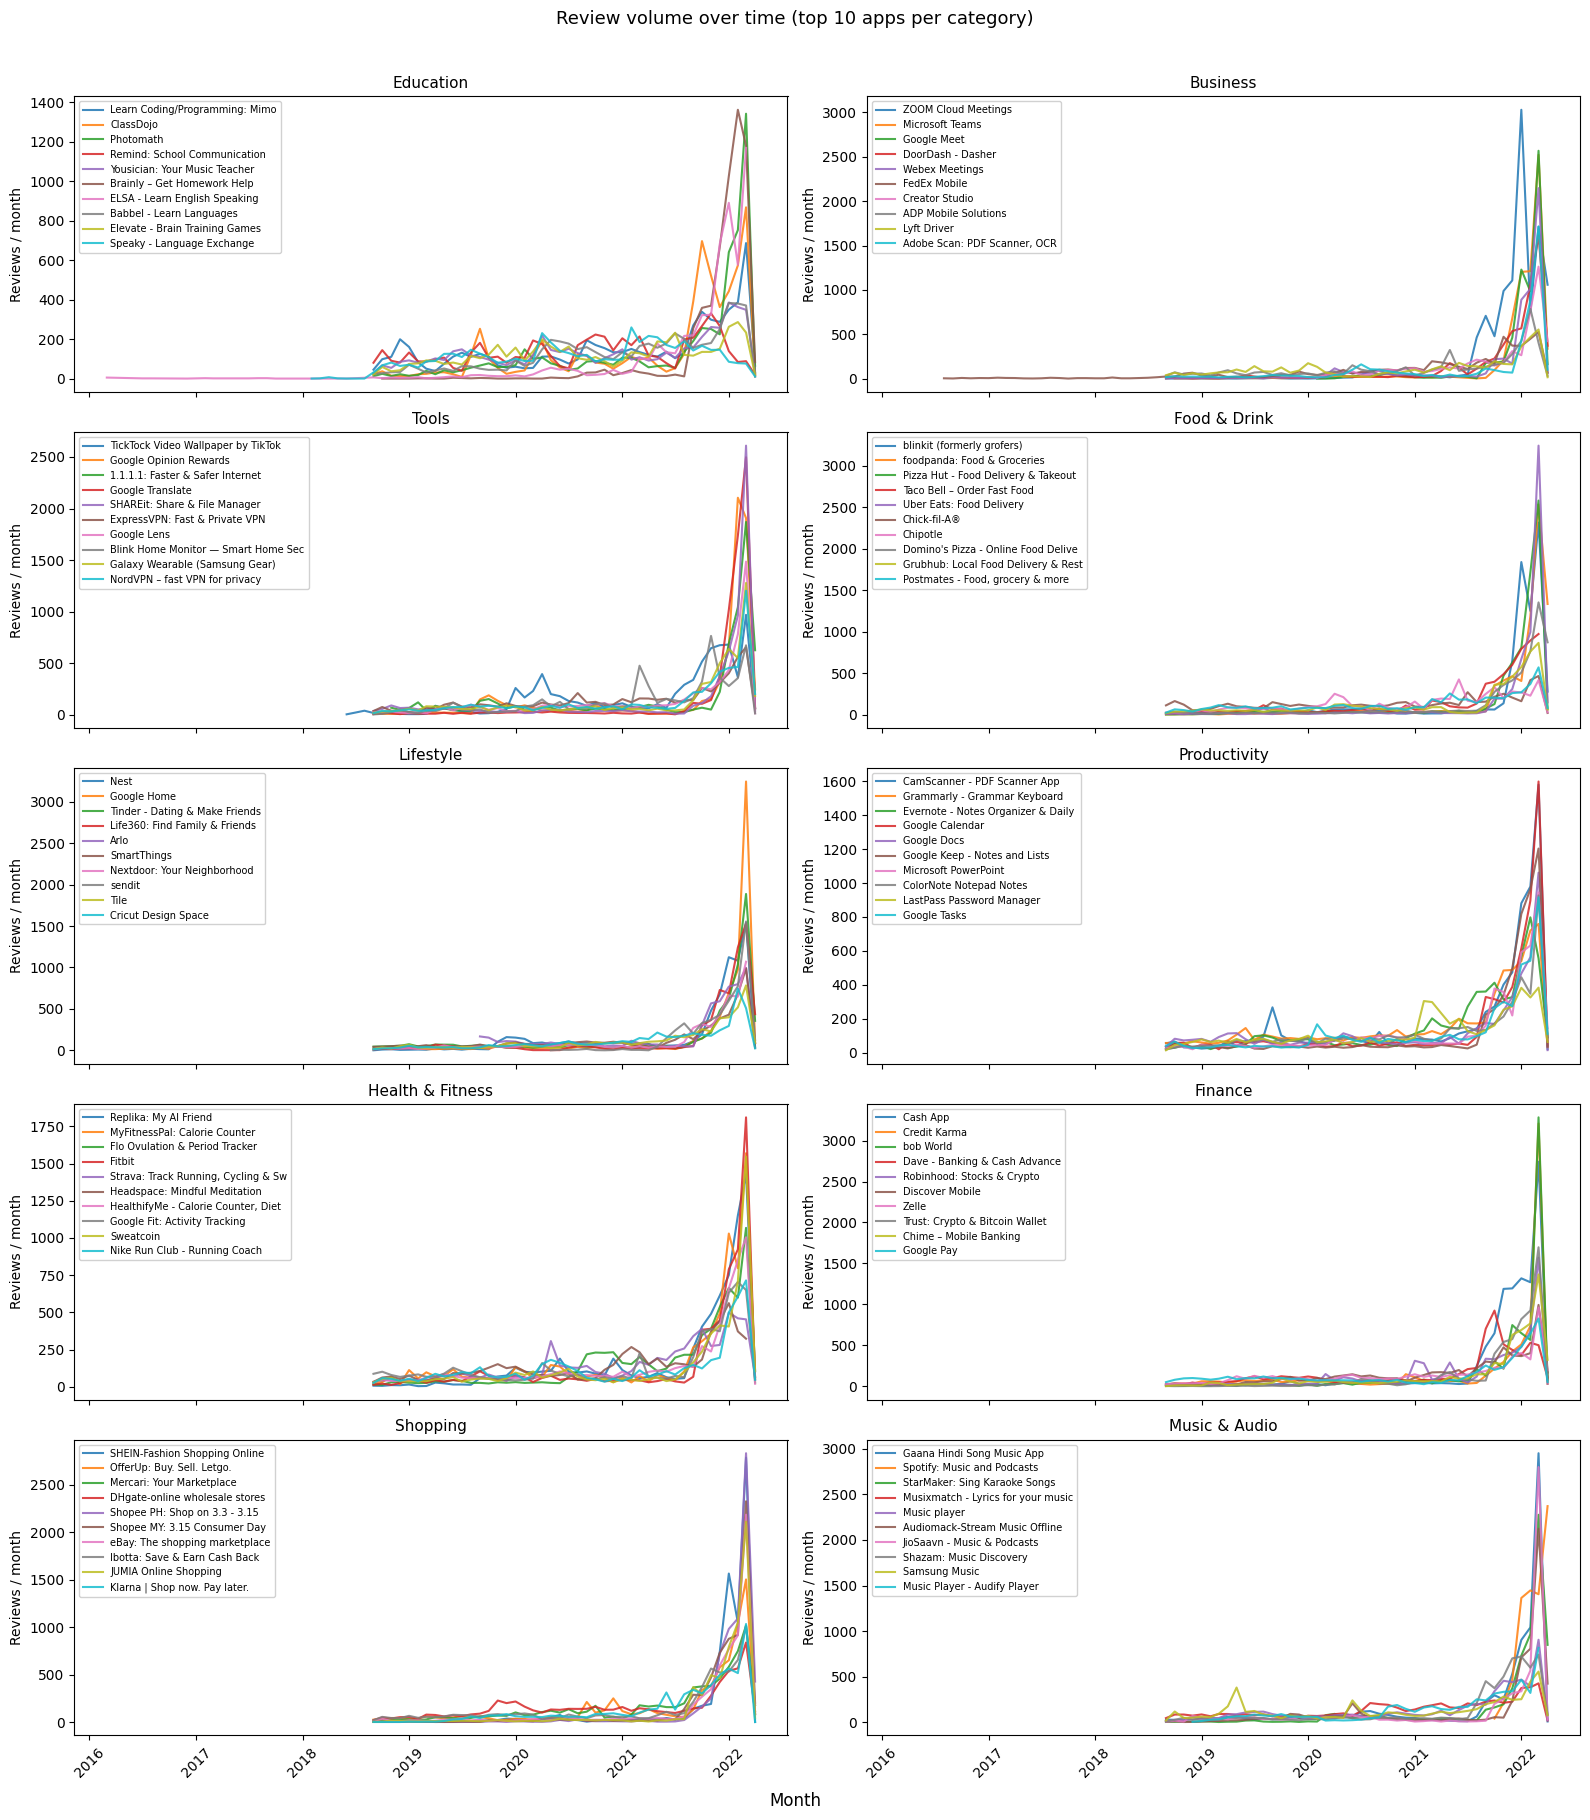

In [ ]:
import matplotlib.pyplot as plt

apps = top_10_apps_per_category["app_package"].tolist()
app_labels = dict(
    zip(top_10_apps_per_category["app_package"], top_10_apps_per_category["app_name"])
)

# Reviews over time for top apps only (Arrow filter, then monthly counts)
table = train.data.table
mask = pc.is_in(table["app_package"], value_set=pa.array(apps))
reviews_ts = table.filter(mask).select(["app_package", "unix_timestamp"]).to_pandas()

reviews_ts["month"] = (
    pd.to_datetime(reviews_ts["unix_timestamp"], unit="s")
    .dt.to_period("M")
    .dt.to_timestamp()
)
monthly = (
    reviews_ts.groupby(["app_package", "month"])
    .size()
    .reset_index(name="reviews")
)

# One subplot per category; each line = one app
fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

for ax, cat in zip(axes, app_categories_filtered):
    cat_pkgs = top_10_apps_per_category.loc[
        top_10_apps_per_category["app_category"] == cat, "app_package"
    ]
    for pkg in cat_pkgs:
        s = monthly[monthly["app_package"] == pkg].sort_values("month")
        ax.plot(
            s["month"],
            s["reviews"],
            label=app_labels[pkg][:35],
            linewidth=1.5,
            alpha=0.85,
        )
    ax.set_title(cat, fontsize=11)
    ax.set_ylabel("Reviews / month")
    ax.legend(fontsize=7, loc="upper left", framealpha=0.9)
    ax.tick_params(axis="x", rotation=45)

fig.supxlabel("Month")
fig.suptitle("Review volume over time (top 10 apps per category)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Only the top 10 apps per category from top_10_apps_per_category
top_apps = top_10_apps_per_category["app_package"].tolist()
pkg_to_cat = dict(
    zip(top_10_apps_per_category["app_package"], top_10_apps_per_category["app_category"])
)

table = train.data.table
mask = pc.is_in(table["app_package"], value_set=pa.array(top_apps))
sub = table.filter(mask).select(["app_package", "unix_timestamp"])
df = sub.to_pandas()
df["app_category"] = df["app_package"].map(pkg_to_cat)

# Per-category stats + peak review day (date with most reviews)
df["date"] = pd.to_datetime(df["unix_timestamp"], unit="s").dt.normalize()
daily = df.groupby(["app_category", "date"], observed=True).size().reset_index(name="n")
peak_rows = daily.loc[daily.groupby("app_category")["n"].idxmax()]

apps_per_cat = (
    top_10_apps_per_category.groupby("app_category", as_index=False)
    .agg(**{"#apps": ("app_package", "count")})
)

review_stats = (
    df.groupby("app_category", observed=True)
    .agg(**{"#reviews": ("app_package", "count")})
    .reset_index()
)

category_summary = (
    apps_per_cat.merge(review_stats, on="app_category")
    .merge(
        peak_rows.assign(
            peak_review_date=peak_rows["date"].dt.strftime("%Y-%m-%d")
        )[["app_category", "peak_review_date"]],
        on="app_category",
    )
)

cat_order = {c: i for i, c in enumerate(app_categories_filtered)}
category_summary = category_summary.sort_values(
    "app_category", key=lambda s: s.map(cat_order)
).reset_index(drop=True)

median_peak = pd.to_datetime(category_summary["peak_review_date"]).median()
totals = pd.DataFrame(
    {
        "app_category": ["Total"],
        "#apps": [category_summary["#apps"].sum()],
        "#reviews": [category_summary["#reviews"].sum()],
        "peak_review_date": [pd.Timestamp(median_peak).strftime("%Y-%m-%d")],
    }
)
category_summary = pd.concat([category_summary, totals], ignore_index=True)

category_summary

,app_category,#apps,#reviews,peak_review_date
0,Education,10,58511,2022-03-15
1,Business,10,61788,2022-03-29
2,Tools,10,65845,2022-03-29
3,Food & Drink,10,63894,2022-03-29
4,Lifestyle,10,60084,2022-03-25
5,Productivity,10,60496,2022-03-28
6,Health & Fitness,10,64670,2022-03-17
7,Finance,10,70048,2022-03-26
8,Shopping,10,67007,2022-03-26
9,Music & Audio,10,63670,2022-03-26


In [21]:
# 30-day batch: top-10 apps per category, ±15 days around the shared median peak date
anchor_peak = pd.to_datetime(
    category_summary.loc[category_summary["app_category"] != "Total", "peak_review_date"]
).median()
window_start = anchor_peak - pd.Timedelta(days=15)
window_end = anchor_peak + pd.Timedelta(days=15)
anchor_str = anchor_peak.strftime("%Y-%m-%d")

top_apps = top_10_apps_per_category["app_package"].tolist()
pkg_to_cat = dict(
    zip(top_10_apps_per_category["app_package"], top_10_apps_per_category["app_category"])
)

table = train.data.table
mask = pc.is_in(table["app_package"], value_set=pa.array(top_apps))
sub = table.filter(mask).select(["app_package", "unix_timestamp"])
df_top = sub.to_pandas()
df_top["app_category"] = df_top["app_package"].map(pkg_to_cat)
df_top["date"] = pd.to_datetime(df_top["unix_timestamp"], unit="s").dt.normalize()

reviews_window_batch = df_top[
    (df_top["date"] >= window_start) & (df_top["date"] <= window_end)
].copy()

apps_per_cat = (
    top_10_apps_per_category.groupby("app_category", as_index=False)
    .agg(**{"#apps": ("app_package", "count")})
)
review_stats = (
    reviews_window_batch.groupby("app_category", observed=True)
    .agg(**{"#reviews": ("app_package", "count")})
    .reset_index()
)

category_summary_window = (
    apps_per_cat.merge(review_stats, on="app_category", how="left")
    .fillna({"#reviews": 0})
    .astype({"#reviews": int})
)
category_summary_window["peak_review_date"] = anchor_str

cat_order = {c: i for i, c in enumerate(app_categories_filtered)}
category_summary_window = category_summary_window.sort_values(
    "app_category", key=lambda s: s.map(cat_order)
).reset_index(drop=True)

totals_window = pd.DataFrame(
    {
        "app_category": ["Total"],
        "#apps": [category_summary_window["#apps"].sum()],
        "#reviews": [category_summary_window["#reviews"].sum()],
        "peak_review_date": [anchor_str],
    }
)
category_summary_window = pd.concat(
    [category_summary_window, totals_window], ignore_index=True
)

print(
    f"30-day window: {window_start.date()} → {window_end.date()} "
    f"(±15 days around {anchor_str})"
)
category_summary_window

30-day window: 2022-03-11 → 2022-04-10 (±15 days around 2022-03-26)


,app_category,#apps,#reviews,peak_review_date
0,Education,10,4689,2022-03-26
1,Business,10,13698,2022-03-26
2,Tools,10,13351,2022-03-26
3,Food & Drink,10,14127,2022-03-26
4,Lifestyle,10,11711,2022-03-26
5,Productivity,10,7810,2022-03-26
6,Health & Fitness,10,7431,2022-03-26
7,Finance,10,15316,2022-03-26
8,Shopping,10,14085,2022-03-26
9,Music & Audio,10,15602,2022-03-26


In [ ]:
from pathlib import Path

OUTPUT_DIR = Path(".")
APPS_CSV = OUTPUT_DIR / "mobilerec_apps.csv"
REVIEWS_CSV = OUTPUT_DIR / "mobilerec_reviews.csv"

top_apps = top_10_apps_per_category["app_package"].tolist()

# App catalog: metadata for the 100 top apps (+ rank from our selection)
apps_export = (
    meta.to_pandas()
    .merge(
        top_10_apps_per_category[["app_package", "rank", "interactions"]],
        on="app_package",
        how="inner",
    )
    .sort_values(["app_category", "rank"])
    .reset_index(drop=True)
)

# Reviews: full interaction rows in the 30-day window for those apps
table = train.data.table
mask = pc.is_in(table["app_package"], value_set=pa.array(top_apps))
reviews_export = table.filter(mask).to_pandas()
reviews_export["_date"] = pd.to_datetime(
    reviews_export["unix_timestamp"], unit="s"
).dt.normalize()
reviews_export = reviews_export[
    (reviews_export["_date"] >= window_start)
    & (reviews_export["_date"] <= window_end)
].drop(columns="_date")

apps_export.to_csv(APPS_CSV, index=False)
reviews_export.to_csv(REVIEWS_CSV, index=False)

print(f"Saved {len(apps_export)} apps → {APPS_CSV.resolve()}")
print(f"Saved {len(reviews_export):,} reviews → {REVIEWS_CSV.resolve()}")

In [ ]:
# Pipeline-ready export: join app_name into reviews, rename columns to match
# the FeClustRE /process_reviews/upload CSV schema.
#
# Required columns by the pipeline:
#   app_name       — used to group reviews per app (CRITICAL: rows without it are dropped)
#   app_package    — stored as app identifier in Neo4j
#   app_categoryId — stored as app category in Neo4j
#   review         — review text fed to the NLP pipeline
#   score          — star rating (int 1-5); defaults to 0 if missing
#   reviewId       — optional; defaults to empty string if missing
#
# MobileRec raw schema differences:
#   rating      → renamed to score
#   app_category → renamed to app_categoryId
#   app_name    → not in reviews; joined from mobilerec_apps.csv via app_package

PIPELINE_CSV = OUTPUT_DIR / mobilerec_reviews_pipeline.csv

pipeline_reviews = (
    reviews_export
    .merge(
        apps_export[["app_package", "app_name"]],
        on="app_package",
        how="left",
    )
    .rename(columns={"rating": "score", "app_category": "app_categoryId"})
    .dropna(subset=["review"])
)

# Reorder: pipeline-critical columns first, rest preserved
priority_cols = ["app_name", "app_package", "app_categoryId", "review", "score"]
remaining_cols = [c for c in pipeline_reviews.columns if c not in priority_cols]
pipeline_reviews = pipeline_reviews[priority_cols + remaining_cols]

pipeline_reviews.to_csv(PIPELINE_CSV, index=False)

print(f"Saved {len(pipeline_reviews):,} pipeline-ready reviews → {PIPELINE_CSV.resolve()}")
print(f"Apps covered: {pipeline_reviews['app_name'].nunique()}")
print(f"Categories covered: {pipeline_reviews['app_categoryId'].nunique()}")
print(f"Missing reviews dropped: {len(reviews_export) - len(pipeline_reviews)}")
print()
print("Schema preview:")
print(pipeline_reviews.dtypes.to_string())
